# 02 — Analyse en composantes principales (ACP)

Le notebook agrège les métriques d'**un seul corpus**, prépare les variables
numériques, impute les valeurs manquantes, standardise les variables puis réalise
une ACP. Les résultats sont écrits dans `analysis/<corpus>/pca/`.


## 1. Configuration


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from metric_registry import get_dataset
from pipeline_utils import detect_project_dir, aggregate_metrics, prepare_numeric_features

PROJECT_DIR = detect_project_dir()
DATASET = "Mirabelle"  # "Mirabelle", "Nowledgeable" ou "Progsnap2"
JOIN_MODE = "outer"
IMPUTATION = "median"  # "median", "mean" ou "drop_rows"
MIN_NON_NULL_FEATURES = 2
DROP_FEATURES = []

SPEC = get_dataset(DATASET)
CSV_DIR = SPEC.csv_dir(PROJECT_DIR)
ANALYSIS_DIR = SPEC.analysis_dir(PROJECT_DIR) / "pca"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
print("Corpus  :", DATASET)
print("CSV     :", CSV_DIR)
print("Analyse :", ANALYSIS_DIR)


Corpus  : Mirabelle
CSV     : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine_nettoyee_2026-08-15\Chaine_nettoyee\csv\Mirabelle
Analyse : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine_nettoyee_2026-08-15\Chaine_nettoyee\analysis\Mirabelle\pca


## 2. Agrégation et nettoyage


In [38]:
features, inventory_df = aggregate_metrics(CSV_DIR, join_mode=JOIN_MODE)
display(inventory_df)

X_raw, usable_cols, removed_df = prepare_numeric_features(
    features,
    drop_features=DROP_FEATURES,
    min_non_null_features=MIN_NON_NULL_FEATURES,
)
if len(usable_cols) < 2:
    raise ValueError("Il faut au moins deux variables numériques non constantes pour une ACP.")
if not removed_df.empty:
    display(removed_df)

missing = X_raw[usable_cols].isna().mean().mul(100).sort_values(ascending=False)
display(missing.rename("pct_manquant").to_frame())


,fichier,statut,raison,lignes,variables
0,attempts_to_first_success.csv,chargé,,44,AttemptsToFirstSuccess
1,code_change_magnitude.csv,chargé,,42,CodeChangeMagnitude
2,error_quotient.csv,chargé,,42,ErrorQuotient
3,error_quotient_fe.csv,chargé,,42,ErrorQuotient_FE
4,exception_run_ratio.csv,chargé,,45,ExceptionTestRunRatio
5,failed_run_ratio.csv,chargé,,45,FailedTestRunRatio
6,first_attempt_success_rate.csv,chargé,,45,FirstAttemptSuccessRate
7,function_coverage.csv,chargé,,49,FunctionCoverage
8,productive_transition_rate.csv,chargé,,37,ProductiveTransitionRate
9,red.csv,chargé,,42,RED


,pct_manquant
ProductiveTransitionRate,21.276596
CodeChangeMagnitude,10.638298
ErrorQuotient_FE,10.638298
ErrorQuotient,10.638298
RED,10.638298
RED_FE,10.638298
UnchangedRerunRatio,8.510638
AttemptsToFirstSuccess,6.382979
TimeToFirstSuccess,6.382979
FirstAttemptSuccessRate,4.255319


## 3. Imputation et standardisation


In [39]:
subject_ids = X_raw["SubjectID"].astype(str).reset_index(drop=True)
X_values = X_raw[usable_cols].copy()

if IMPUTATION == "drop_rows":
    keep = X_values.notna().all(axis=1)
    X_values = X_values.loc[keep].reset_index(drop=True)
    subject_ids = subject_ids.loc[keep].reset_index(drop=True)
elif IMPUTATION in {"median", "mean"}:
    imputer = SimpleImputer(strategy=IMPUTATION)
    X_values = pd.DataFrame(imputer.fit_transform(X_values), columns=usable_cols)
else:
    raise ValueError("IMPUTATION doit valoir 'median', 'mean' ou 'drop_rows'.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

features_for_pca = pd.concat([subject_ids.rename("SubjectID"), X_values], axis=1)
features_for_pca.to_csv(ANALYSIS_DIR / "features_for_pca.csv", index=False)
print(f"{len(subject_ids)} étudiant(s), {len(usable_cols)} variable(s).")


47 étudiant(s), 16 variable(s).


## 4. ACP et fichiers de résultats


In [40]:
pca = PCA()
scores = pca.fit_transform(X_scaled)
component_names = [f"PC{i+1}" for i in range(scores.shape[1])]

explained_df = pd.DataFrame({
    "component": component_names,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_pct": pca.explained_variance_ratio_ * 100,
    "cumulative_variance_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
})

scores_df = pd.DataFrame(scores, columns=component_names)
scores_df.insert(0, "SubjectID", subject_ids.values)

# Les loadings ci-dessous sont les corrélations variable-composante pour des
# données standardisées : composantes * sqrt(valeurs propres).
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=component_names)
loadings_df.insert(0, "variable", usable_cols)

explained_df.to_csv(ANALYSIS_DIR / "explained_variance.csv", index=False)
scores_df.to_csv(ANALYSIS_DIR / "pca_scores.csv", index=False)
loadings_df.to_csv(ANALYSIS_DIR / "pca_loadings.csv", index=False)

display(explained_df.head(10))


,component,explained_variance_ratio,explained_variance_pct,cumulative_variance_pct
0,PC1,0.315633,31.563270,31.563270
1,PC2,0.253887,25.388705,56.951975
2,PC3,0.134446,13.444555,70.396530
3,PC4,0.087664,8.766396,79.162926
4,PC5,0.057339,5.733947,84.896873
5,PC6,0.050608,5.060762,89.957634
6,PC7,0.030837,3.083697,93.041331
7,PC8,0.024510,2.451010,95.492341
8,PC9,0.016006,1.600583,97.092923
9,PC10,0.009438,0.943828,98.036751


## 5. Variance expliquée


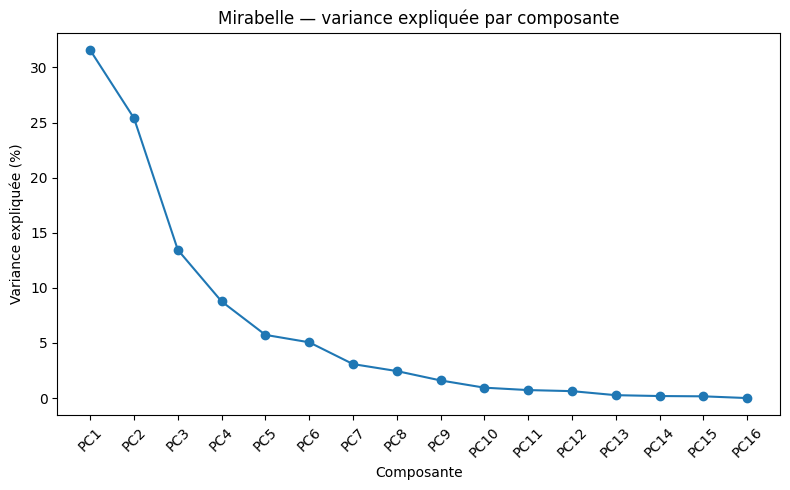

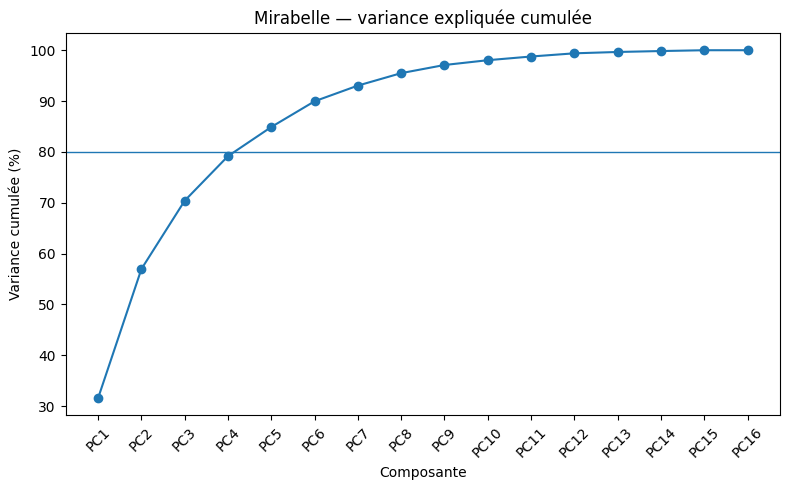

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(explained_df["component"], explained_df["explained_variance_pct"], marker="o")
plt.xlabel("Composante")
plt.ylabel("Variance expliquée (%)")
plt.title(f"{DATASET} — variance expliquée par composante")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(explained_df["component"], explained_df["cumulative_variance_pct"], marker="o")
plt.axhline(80, linewidth=1)
plt.xlabel("Composante")
plt.ylabel("Variance cumulée (%)")
plt.title(f"{DATASET} — variance expliquée cumulée")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Projection et contributions principales


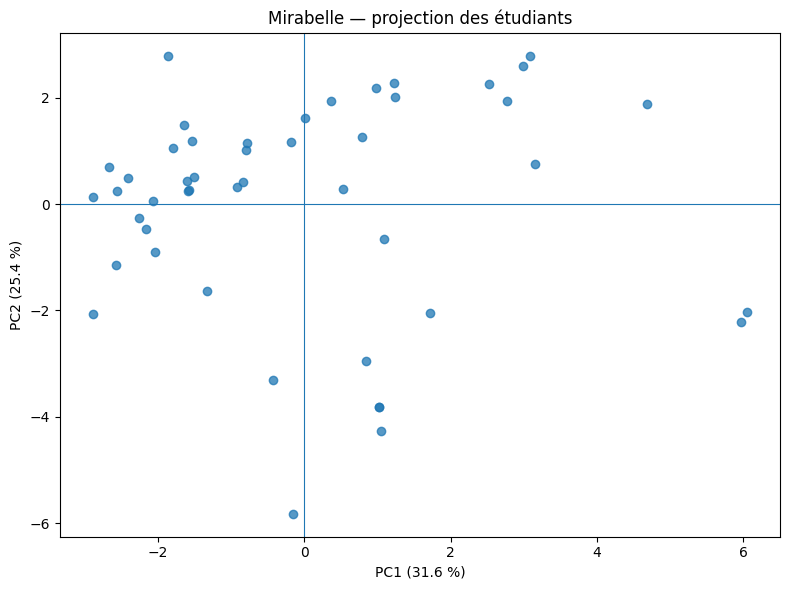


Variables les plus liées à PC1


,variable,PC1
3,ErrorQuotient_FE,0.943716
2,ErrorQuotient,0.939916
9,RED,0.926504
10,RED_FE,0.911453
5,FailedTestRunRatio,0.745888
6,FirstAttemptSuccessRate,-0.482593
4,ExceptionTestRunRatio,0.466060
0,AttemptsToFirstSuccess,0.453164
8,ProductiveTransitionRate,-0.341341
11,SessionCount,-0.329416



Variables les plus liées à PC2


,variable,PC2
12,SessionSpanMinutes,0.797933
11,SessionCount,0.719098
7,FunctionCoverage,0.700125
4,ExceptionTestRunRatio,-0.671031
13,TestPassRate,0.655065
14,TimeToFirstSuccess,0.642017
0,AttemptsToFirstSuccess,0.608598
6,FirstAttemptSuccessRate,0.427782
1,CodeChangeMagnitude,-0.393113
5,FailedTestRunRatio,-0.368770



Variables les plus liées à PC3


,variable,PC3
6,FirstAttemptSuccessRate,0.722302
13,TestPassRate,0.632831
1,CodeChangeMagnitude,-0.572114
14,TimeToFirstSuccess,-0.514447
0,AttemptsToFirstSuccess,-0.418257
8,ProductiveTransitionRate,-0.358116
12,SessionSpanMinutes,-0.328890
5,FailedTestRunRatio,-0.274184
11,SessionCount,-0.243606
4,ExceptionTestRunRatio,0.233947



Variables les plus liées à PC4


,variable,PC4
15,UnchangedRerunRatio,0.800136
1,CodeChangeMagnitude,-0.545876
4,ExceptionTestRunRatio,0.377149
5,FailedTestRunRatio,0.341002
7,FunctionCoverage,0.175631
12,SessionSpanMinutes,0.174443
13,TestPassRate,0.167824
8,ProductiveTransitionRate,0.165244
2,ErrorQuotient,-0.161983
9,RED,-0.151815



Variables les plus liées à PC5


,variable,PC5
8,ProductiveTransitionRate,0.676074
11,SessionCount,-0.336652
12,SessionSpanMinutes,-0.321064
14,TimeToFirstSuccess,0.273498
7,FunctionCoverage,-0.265669
0,AttemptsToFirstSuccess,0.204368
13,TestPassRate,0.188450
5,FailedTestRunRatio,-0.116193
1,CodeChangeMagnitude,-0.108035
6,FirstAttemptSuccessRate,0.105442


In [42]:
if len(component_names) >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.75)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel(f"PC1 ({explained_df.loc[0, 'explained_variance_pct']:.1f} %)")
    plt.ylabel(f"PC2 ({explained_df.loc[1, 'explained_variance_pct']:.1f} %)")
    plt.title(f"{DATASET} — projection des étudiants")
    plt.tight_layout()
    plt.show()

for pc in component_names[:min(5, len(component_names))]:
    tmp = loadings_df[["variable", pc]].copy()
    tmp["abs_loading"] = tmp[pc].abs()
    print()
    print(f"Variables les plus liées à {pc}")
    display(tmp.sort_values("abs_loading", ascending=False).head(10).drop(columns="abs_loading"))


## 7. Matrice de corrélation


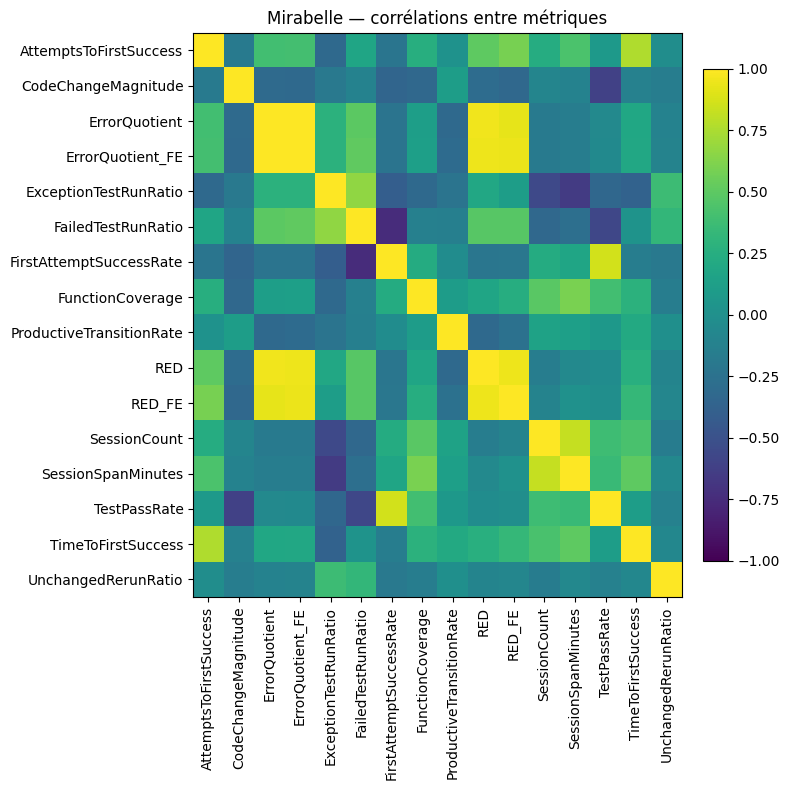

In [43]:
corr = features_for_pca[usable_cols].corr()
plt.figure(figsize=(max(8, 0.5 * len(usable_cols)), max(6, 0.5 * len(usable_cols))))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(usable_cols)), usable_cols, rotation=90)
plt.yticks(range(len(usable_cols)), usable_cols)
plt.title(f"{DATASET} — corrélations entre métriques")
plt.tight_layout()
plt.show()
